# Notebook 28 - Baseline-normalized final-output checkpoint

Question from the visual inspection:

> Are Python and MATLAB mostly different because the user-selected ROI gives a different resting baseline, while the contraction dynamics are similar?

This notebook compares raw and baseline-normalized outputs.

Current Python final-output candidate:

```text
ANG = Python dohough weighted-median alpha
PEN = Python alpha - Python superficial aponeurosis angle
FL  = Python thickness / sin(PEN), converted to mm
```

This is **not** a code-change notebook. It is the last notebook checkpoint before deciding what should be moved into `ultrasound_tracker` on the next branch.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_final_region_arrays,
    extract_geofeature_arrays,
    load_matlab_result,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY23_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_METRICS = OUT_DIR / "notebook28_baseline_normalized_metrics.csv"
OUT_SPLIT_METRICS = OUT_DIR / "notebook28_rest_vs_contraction_metrics.csv"
OUT_BASELINES = OUT_DIR / "notebook28_baseline_offsets.csv"
OUT_NPZ = OUT_DIR / "notebook28_baseline_normalized_arrays.npz"

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

for path in [VIDEO_PATH, MATLAB_RESULT, PY23_NPZ]:
    print(path, "exists=", path.exists())

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz exists= True


## 1. Load MATLAB final outputs and current Python candidate

`Region.ANG/PEN/FL` are the MATLAB final UltraTimTrack outputs.

The Python candidate here uses notebook 23 arrays and the same pixel-to-mm conversion used previously: MATLAB image depth divided by video image height.

In [2]:
mat = load_matlab_result(MATLAB_RESULT)
mat_region = extract_final_region_arrays(mat)
mat_geo = extract_geofeature_arrays(mat)
py = np.load(PY23_NPZ)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
ret, frame0 = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")

image_height_px = frame0.shape[0]
image_depth_mm = float(mat_region["image_depth_mm"])
mm_per_px = image_depth_mm / image_height_px

n = min(
    len(mat_region["fascicle_angle_deg"]),
    len(mat_region["pennation_deg"]),
    len(mat_region["length_mm"]),
    len(py["fascicle_angle_deg"]),
)

time_s = np.asarray(py["time_s"][:n], dtype=float)
frame = np.asarray(py["frame"][:n], dtype=int)

mat_ang = np.asarray(mat_region["fascicle_angle_deg"][:n], dtype=float)
mat_pen = np.asarray(mat_region["pennation_deg"][:n], dtype=float)
mat_fl = np.asarray(mat_region["length_mm"][:n], dtype=float)

py_ang = np.asarray(py["fascicle_angle_deg"][:n], dtype=float)
py_pen = np.asarray(py["pennation_angle_deg"][:n], dtype=float)
py_fl = np.asarray(py["matlab_formula_fascicle_length_px"][:n], dtype=float) * mm_per_px
py_selected_fl = np.asarray(py["selected_line_length_px"][:n], dtype=float) * mm_per_px

mat_timtrack_alpha = np.asarray(mat_geo["alpha_deg"][:n], dtype=float)
mat_timtrack_faslen = np.asarray(mat_geo["faslen_px"][:n], dtype=float) * mm_per_px

print("Aligned frames:", n)
print("FPS:", fps)
print("image_height_px:", image_height_px)
print("image_depth_mm:", image_depth_mm)
print("mm_per_px:", mm_per_px)

Aligned frames: 2666
FPS: 33.341
image_height_px: 562
image_depth_mm: 50.7
mm_per_px: 0.09021352313167261


## 2. Baseline definition

The default baseline is the first 100 frames. This is deliberately robust: each signal uses its own median over the same frame window.

If the MATLAB and Python ROIs represent slightly different anatomical zones, the absolute baseline can differ while the delta-from-baseline dynamics remain similar.

In [3]:
BASELINE_START = 0
BASELINE_STOP = 100

baseline_mask = np.zeros(n, dtype=bool)
baseline_mask[BASELINE_START:min(BASELINE_STOP, n)] = True

# High-angle contraction-like frames. This is a simple visual split, not a formal cycle detector.
CONTRACTION_QUANTILE = 0.75
contraction_threshold = float(np.nanquantile(mat_ang, CONTRACTION_QUANTILE))
contraction_mask = mat_ang >= contraction_threshold

print("Baseline frames:", int(baseline_mask.sum()), f"rows {BASELINE_START}:{BASELINE_STOP}")
print("Baseline time window:", float(time_s[baseline_mask][0]), "to", float(time_s[baseline_mask][-1]), "s")
print("Contraction-like threshold from MATLAB Region.ANG:", contraction_threshold)
print("Contraction-like frames:", int(contraction_mask.sum()))

def robust_baseline(x, mask=baseline_mask):
    return float(np.nanmedian(np.asarray(x, dtype=float)[mask]))

signals = {
    "ANG_deg": {"matlab": mat_ang, "python": py_ang, "unit": "deg"},
    "PEN_deg": {"matlab": mat_pen, "python": py_pen, "unit": "deg"},
    "FL_mm": {"matlab": mat_fl, "python": py_fl, "unit": "mm"},
}

baseline_rows = []
for name, item in signals.items():
    m0 = robust_baseline(item["matlab"])
    p0 = robust_baseline(item["python"])
    item["matlab_baseline"] = m0
    item["python_baseline"] = p0
    item["matlab_delta"] = item["matlab"] - m0
    item["python_delta"] = item["python"] - p0
    baseline_rows.append({
        "signal": name,
        "unit": item["unit"],
        "matlab_baseline": m0,
        "python_baseline": p0,
        "python_minus_matlab_baseline": p0 - m0,
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(OUT_BASELINES, index=False)
display(baseline_df)
print("Saved baselines:", OUT_BASELINES)

Baseline frames: 100 rows 0:100
Baseline time window: 0.0 to 2.9693169593811035 s
Contraction-like threshold from MATLAB Region.ANG: 29.991403390514545
Contraction-like frames: 667


,signal,unit,matlab_baseline,python_baseline,python_minus_matlab_baseline
0,ANG_deg,deg,21.404714,24.000000,2.595286
1,PEN_deg,deg,22.315577,24.681313,2.365735
2,FL_mm,mm,63.150415,58.321727,-4.828689


Saved baselines: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook28_baseline_offsets.csv


## 3. Raw final outputs

These are the absolute values. If ROI placement differs, this is where baseline offsets should show up most clearly.

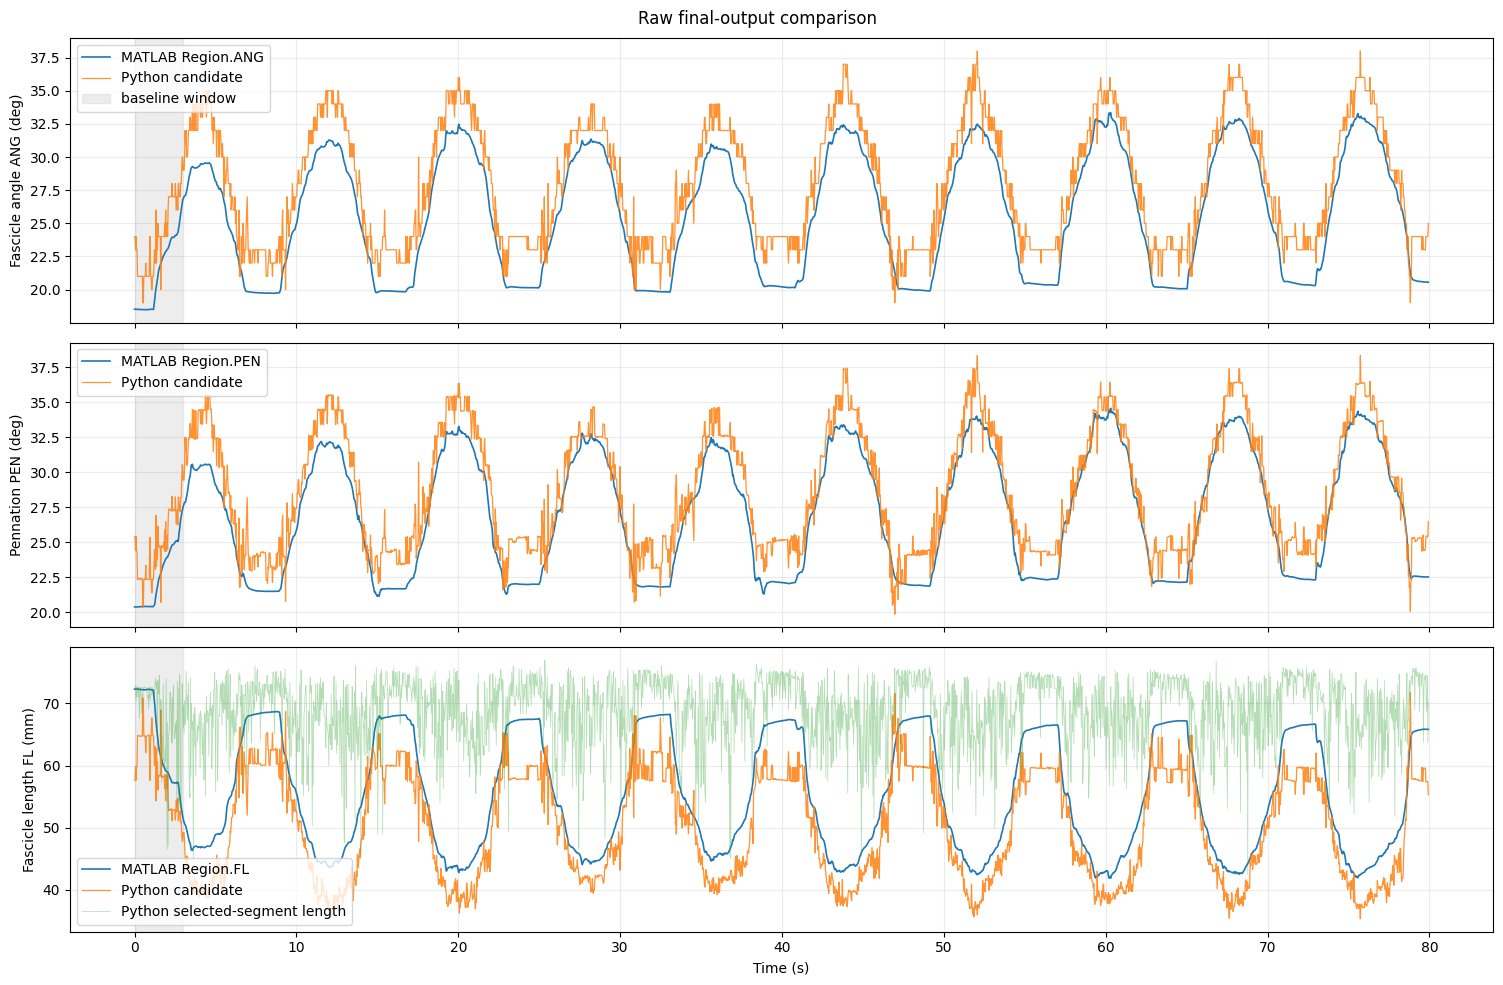

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plot_specs = [
    ("ANG_deg", "Fascicle angle ANG (deg)"),
    ("PEN_deg", "Pennation PEN (deg)"),
    ("FL_mm", "Fascicle length FL (mm)"),
]

for ax, (name, ylabel) in zip(axes, plot_specs):
    item = signals[name]
    ax.plot(time_s, item["matlab"], label=f"MATLAB Region.{name.split('_')[0]}", linewidth=1.2)
    ax.plot(time_s, item["python"], label="Python candidate", linewidth=0.9, alpha=0.85)
    if name == "FL_mm":
        ax.plot(time_s, py_selected_fl, label="Python selected-segment length", linewidth=0.55, alpha=0.35)
    ax.axvspan(time_s[baseline_mask][0], time_s[baseline_mask][-1], color="0.8", alpha=0.35, label="baseline window" if name == "ANG_deg" else None)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw final-output comparison")
plt.tight_layout()
plt.show()

## 4. Baseline-normalized outputs

Each curve has its own median baseline subtracted from the same first-100-frame window.

If the delta curves match much better than the raw curves, ROI/baseline offset is a major part of the difference.

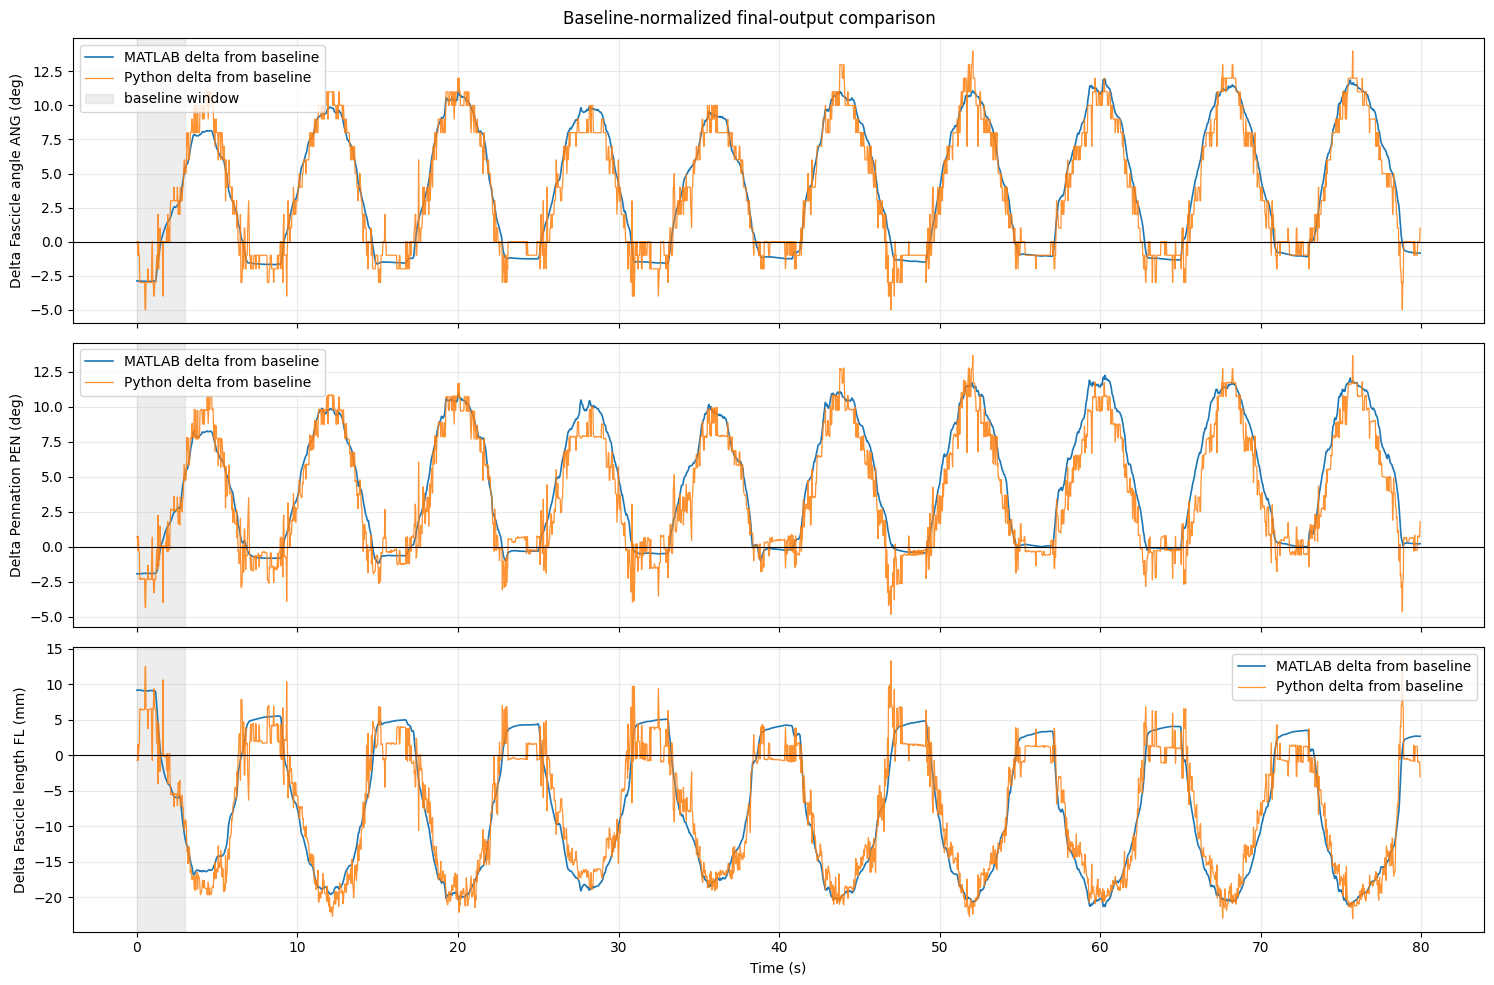

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, (name, ylabel) in zip(axes, plot_specs):
    item = signals[name]
    ax.plot(time_s, item["matlab_delta"], label="MATLAB delta from baseline", linewidth=1.2)
    ax.plot(time_s, item["python_delta"], label="Python delta from baseline", linewidth=0.9, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvspan(time_s[baseline_mask][0], time_s[baseline_mask][-1], color="0.8", alpha=0.35, label="baseline window" if name == "ANG_deg" else None)
    ax.set_ylabel("Delta " + ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Baseline-normalized final-output comparison")
plt.tight_layout()
plt.show()

## 5. Rest and contraction zooms

These show the two regimes separately:

- baseline/rest window,
- high-angle contraction-like frames around the largest MATLAB ANG peak.

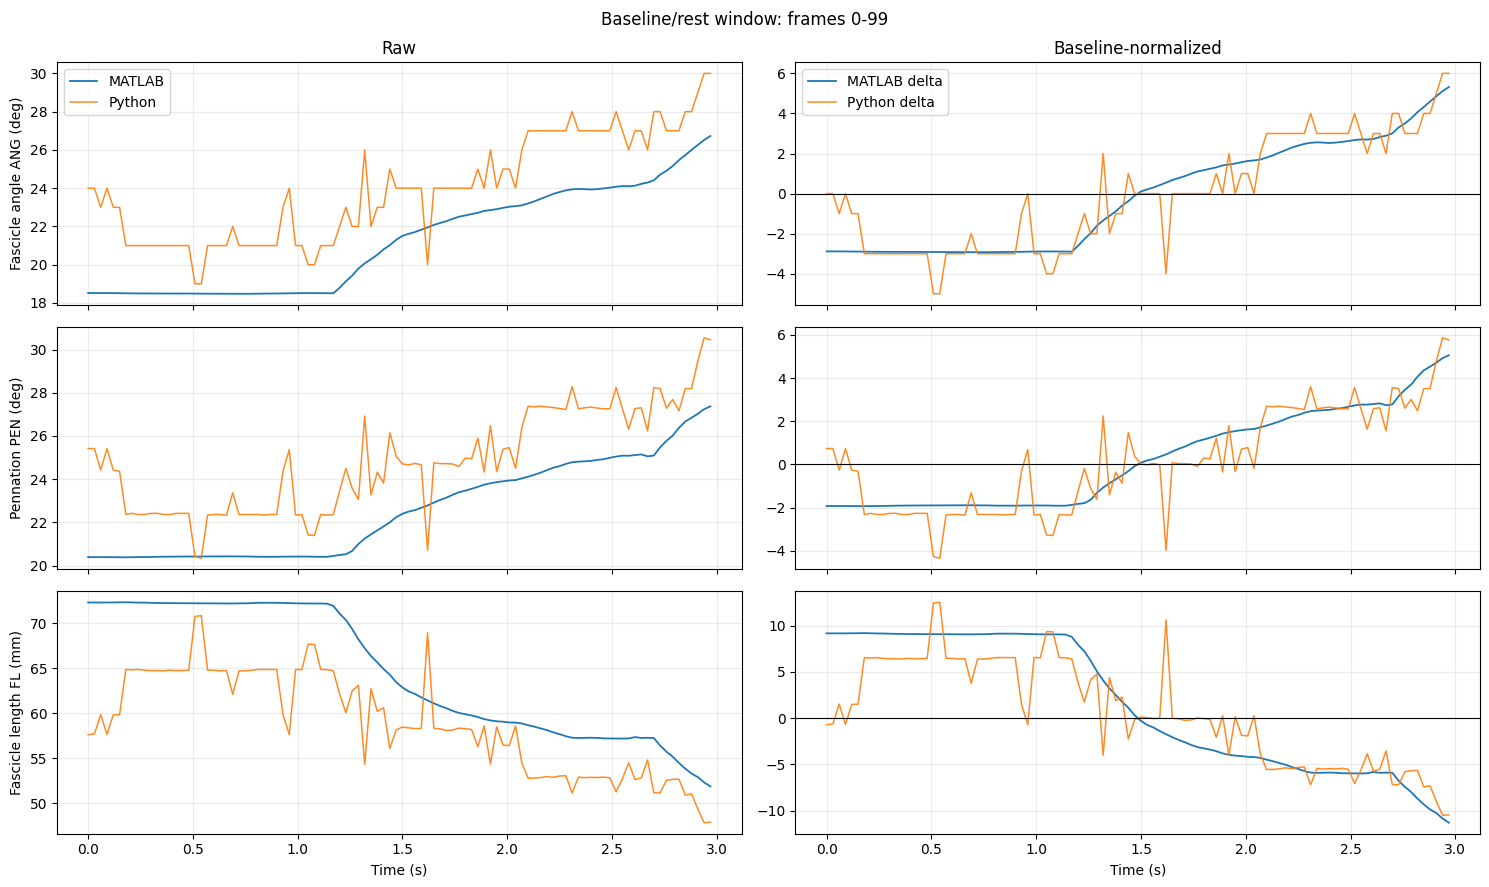

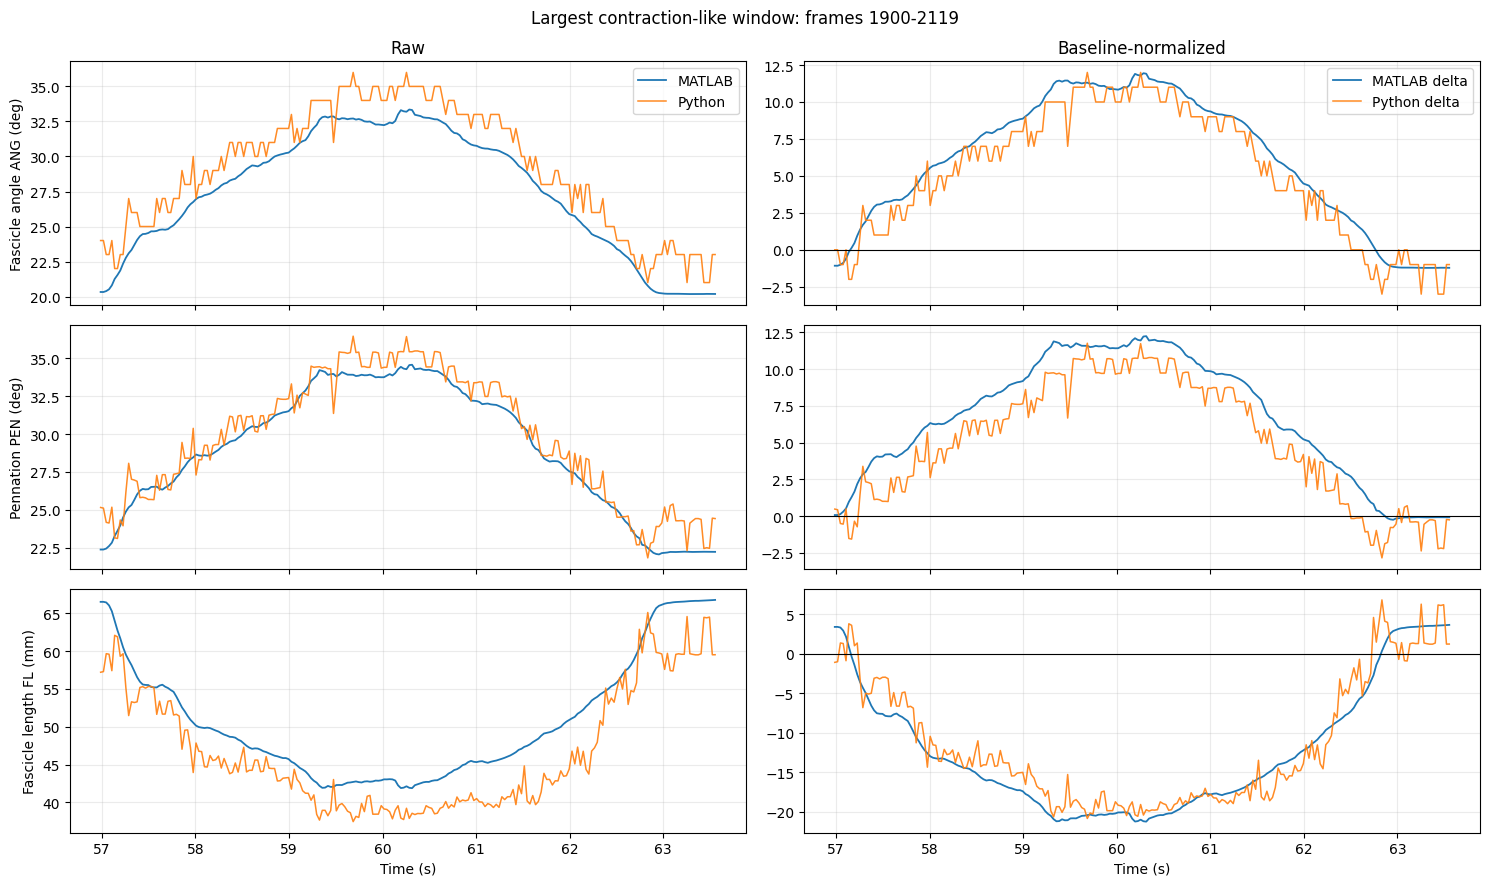

In [6]:
peak_idx = int(np.nanargmax(mat_ang))
window = 220
zoom_slices = [
    ("Baseline/rest window", slice(BASELINE_START, min(BASELINE_STOP, n))),
    ("Largest contraction-like window", slice(max(0, peak_idx - window // 2), min(n, peak_idx + window // 2))),
]

for title, sl in zoom_slices:
    fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex="col")
    for r, (name, ylabel) in enumerate(plot_specs):
        item = signals[name]
        axes[r, 0].plot(time_s[sl], item["matlab"][sl], label="MATLAB", linewidth=1.3)
        axes[r, 0].plot(time_s[sl], item["python"][sl], label="Python", linewidth=1.1, alpha=0.9)
        axes[r, 0].set_ylabel(ylabel)
        axes[r, 0].grid(True, alpha=0.25)
        if r == 0:
            axes[r, 0].set_title("Raw")
            axes[r, 0].legend()

        axes[r, 1].plot(time_s[sl], item["matlab_delta"][sl], label="MATLAB delta", linewidth=1.3)
        axes[r, 1].plot(time_s[sl], item["python_delta"][sl], label="Python delta", linewidth=1.1, alpha=0.9)
        axes[r, 1].axhline(0, color="black", linewidth=0.8)
        axes[r, 1].grid(True, alpha=0.25)
        if r == 0:
            axes[r, 1].set_title("Baseline-normalized")
            axes[r, 1].legend()

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    fig.suptitle(f"{title}: frames {frame[sl][0]}-{frame[sl][-1]}")
    plt.tight_layout()
    plt.show()

## 6. Raw vs delta metrics

The raw metrics answer: how close are absolute values?

The delta metrics answer: how close are changes from rest/baseline?

In [7]:
def metric_row(name, reference, estimate, unit, domain):
    row = {"comparison": name, "unit": unit, "domain": domain}
    row.update(compute_metrics(reference, estimate))
    return row

metric_rows = []
for name, item in signals.items():
    label = name.replace("_", " ")
    metric_rows.append(metric_row(f"raw {label}", item["matlab"], item["python"], item["unit"], "all_frames"))
    metric_rows.append(metric_row(f"delta {label}", item["matlab_delta"], item["python_delta"], item["unit"], "all_frames"))

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUT_METRICS, index=False)
display(metrics)
print("Saved metrics:", OUT_METRICS)

,comparison,unit,domain,n,bias,mae,rmse,corr
0,raw ANG deg,deg,all_frames,2666,2.351215,2.382489,2.612432,0.968938
1,delta ANG deg,deg,all_frames,2666,-0.244071,0.912090,1.164543,0.968938
2,raw PEN deg,deg,all_frames,2666,1.642799,1.754320,2.040973,0.960301
3,delta PEN deg,deg,all_frames,2666,-0.722936,1.103759,1.410467,0.960301
4,raw FL mm,mm,all_frames,2666,-4.993746,5.115188,5.730871,0.954772
5,delta FL mm,mm,all_frames,2666,-0.165058,2.253666,2.816492,0.954772


Saved metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook28_baseline_normalized_metrics.csv


## 7. Rest vs contraction-like metrics

These metrics answer the user's visual hypothesis directly:

- At rest/baseline, absolute offsets may be ROI-dependent.
- During contraction, the dynamic shape may be more important than the absolute baseline.

In [8]:
def masked_metrics(signal_name, item, mask, domain_name):
    label = signal_name.replace("_", " ")
    return [
        metric_row(f"raw {label}", item["matlab"][mask], item["python"][mask], item["unit"], domain_name),
        metric_row(f"delta {label}", item["matlab_delta"][mask], item["python_delta"][mask], item["unit"], domain_name),
    ]

split_rows = []
for name, item in signals.items():
    split_rows.extend(masked_metrics(name, item, baseline_mask, "baseline_window"))
    split_rows.extend(masked_metrics(name, item, contraction_mask, "high_angle_contraction_like"))

split_metrics = pd.DataFrame(split_rows)
split_metrics.to_csv(OUT_SPLIT_METRICS, index=False)
display(split_metrics)
print("Saved split metrics:", OUT_SPLIT_METRICS)

,comparison,unit,domain,n,bias,mae,rmse,corr
0,raw ANG deg,deg,baseline_window,100,2.686444,2.725444,2.915672,0.912039
1,delta ANG deg,deg,baseline_window,100,0.091158,0.770522,1.136868,0.912039
2,raw ANG deg,deg,high_angle_contraction_like,667,2.238347,2.254407,2.448883,0.752975
3,delta ANG deg,deg,high_angle_contraction_like,667,-0.356939,0.855274,1.055575,0.752975
4,raw PEN deg,deg,baseline_window,100,2.258574,2.301749,2.525343,0.877512
5,delta PEN deg,deg,baseline_window,100,-0.107162,0.818797,1.134762,0.877512
6,raw PEN deg,deg,high_angle_contraction_like,667,1.543811,1.602612,1.856855,0.689902
7,delta PEN deg,deg,high_angle_contraction_like,667,-0.821925,1.060216,1.319135,0.689902
8,raw FL mm,mm,baseline_window,100,-5.747583,5.897972,6.731049,0.871097
9,delta FL mm,mm,baseline_window,100,-0.918895,2.632615,3.621695,0.871097


Saved split metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook28_rest_vs_contraction_metrics.csv


## 8. Scatter plots: raw and delta

The delta scatter removes the baseline offset. A better slope/correlation after normalization supports the ROI-offset explanation.

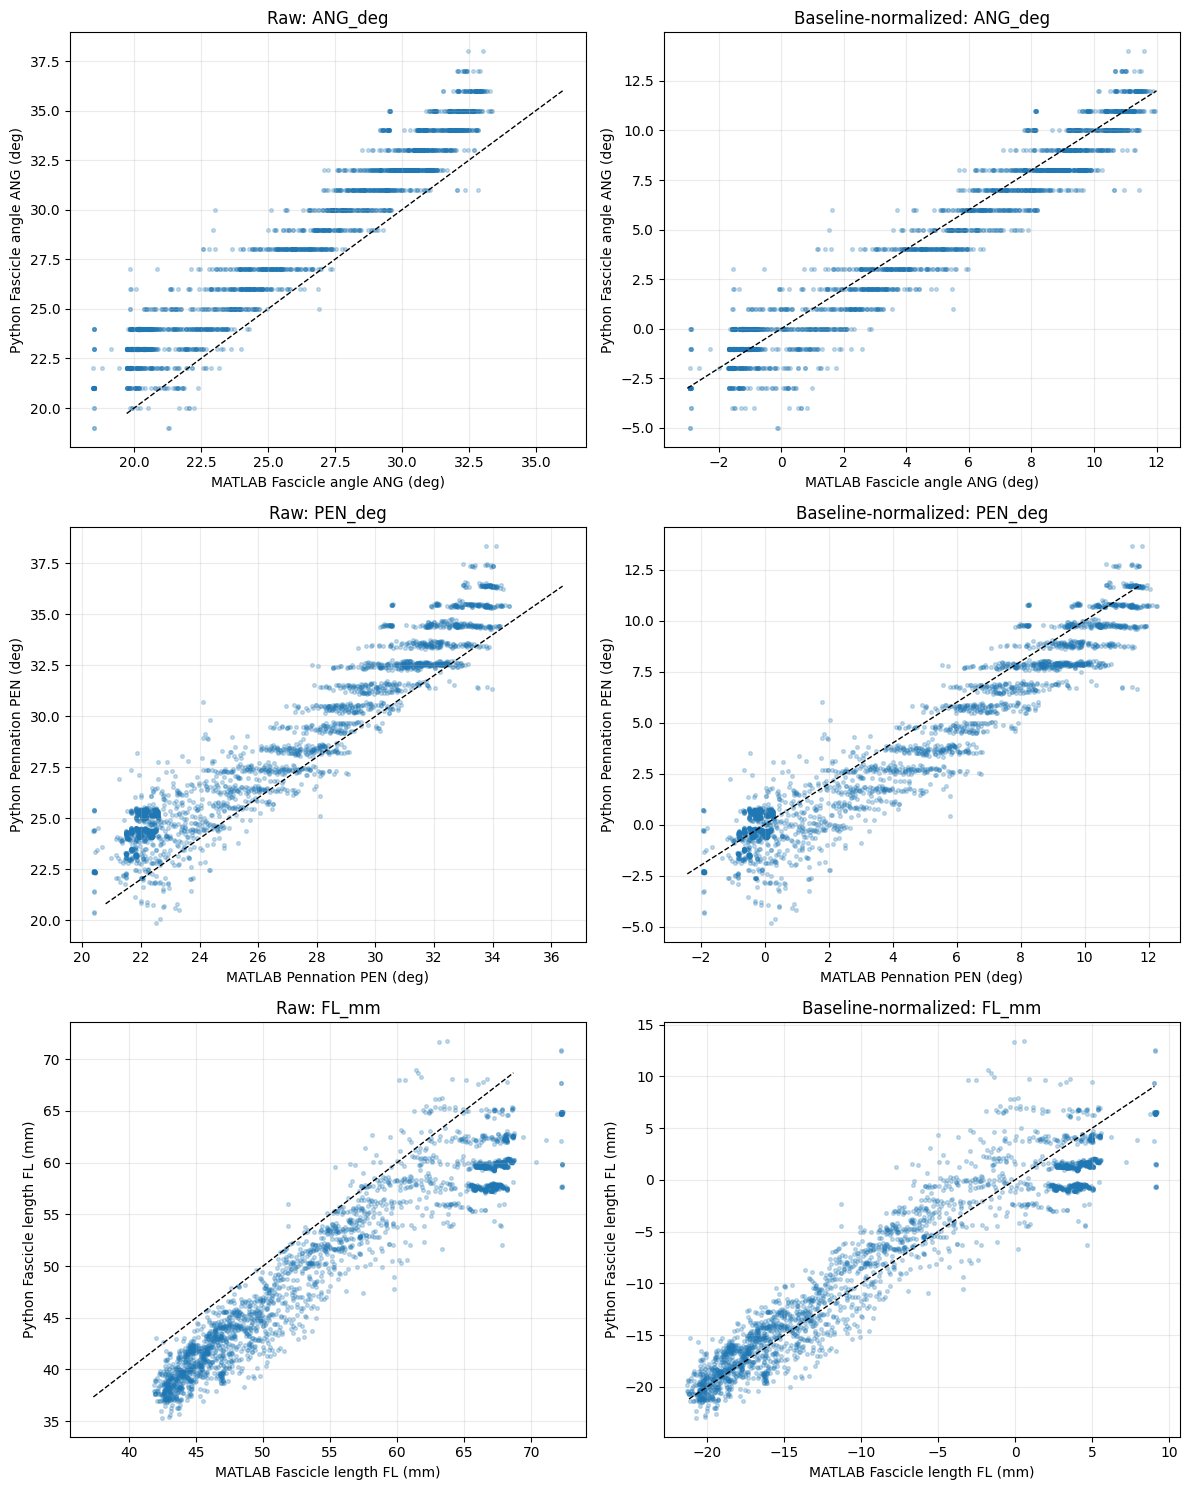

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for r, (name, ylabel) in enumerate(plot_specs):
    item = signals[name]
    raw_x, raw_y = item["matlab"], item["python"]
    delta_x, delta_y = item["matlab_delta"], item["python_delta"]

    for c, (x, y, title) in enumerate([
        (raw_x, raw_y, "Raw"),
        (delta_x, delta_y, "Baseline-normalized"),
    ]):
        ax = axes[r, c]
        ax.scatter(x, y, s=7, alpha=0.25)
        lo = float(np.nanpercentile(np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]]), 1))
        hi = float(np.nanpercentile(np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]]), 99))
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
        ax.set_xlabel(f"MATLAB {ylabel}")
        ax.set_ylabel(f"Python {ylabel}")
        ax.set_title(f"{title}: {name}")
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Dynamic range and normalized error

This helps interpret whether an MAE is large relative to the movement amplitude.

In [10]:
def dynamic_range(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanpercentile(x, 95) - np.nanpercentile(x, 5))

range_rows = []
for name, item in signals.items():
    m_range = dynamic_range(item["matlab_delta"])
    p_range = dynamic_range(item["python_delta"])
    delta_metrics = metrics[metrics["comparison"] == f"delta {name.replace('_', ' ')}"].iloc[0]
    range_rows.append({
        "signal": name,
        "unit": item["unit"],
        "matlab_delta_p95_p05_range": m_range,
        "python_delta_p95_p05_range": p_range,
        "python_range_minus_matlab_range": p_range - m_range,
        "delta_mae": delta_metrics["mae"],
        "delta_mae_over_matlab_range": delta_metrics["mae"] / m_range if m_range else np.nan,
    })

range_df = pd.DataFrame(range_rows)
display(range_df)

,signal,unit,matlab_delta_p95_p05_range,python_delta_p95_p05_range,python_range_minus_matlab_range,delta_mae,delta_mae_over_matlab_range
0,ANG_deg,deg,12.491320,13.000000,0.508680,0.912090,0.073018
1,PEN_deg,deg,11.994944,12.441738,0.446794,1.103759,0.092019
2,FL_mm,mm,25.103667,24.381674,-0.721993,2.253666,0.089774


## 10. Interpretation for package changes

Use this notebook to decide whether the next branch should update `ultrasound_tracker`.

Suggested decision rules:

1. If delta `ANG` is close and strongly correlated, stop chasing Hough alpha parity for now.
2. If delta `FL` is much better than raw `FL`, document the ROI baseline issue and build final outputs around change-from-baseline comparisons when validating.
3. If raw and delta `FL` are both still materially off, then package work should focus first on aponeurosis/thickness/final-length construction, not on selected OpenCV line length.
4. The selected-segment length should remain a visualization/debug output, not the final `FL` candidate.

In [11]:
np.savez(
    OUT_NPZ,
    frame=frame,
    time_s=time_s,
    baseline_mask=baseline_mask,
    contraction_mask=contraction_mask,
    mm_per_px=mm_per_px,
    matlab_ang=mat_ang,
    python_ang=py_ang,
    matlab_pen=mat_pen,
    python_pen=py_pen,
    matlab_fl_mm=mat_fl,
    python_fl_mm=py_fl,
    python_selected_fl_mm=py_selected_fl,
    matlab_ang_delta=signals["ANG_deg"]["matlab_delta"],
    python_ang_delta=signals["ANG_deg"]["python_delta"],
    matlab_pen_delta=signals["PEN_deg"]["matlab_delta"],
    python_pen_delta=signals["PEN_deg"]["python_delta"],
    matlab_fl_delta=signals["FL_mm"]["matlab_delta"],
    python_fl_delta=signals["FL_mm"]["python_delta"],
    matlab_timtrack_alpha=mat_timtrack_alpha,
    matlab_timtrack_faslen_mm=mat_timtrack_faslen,
)
print("Saved arrays:", OUT_NPZ)

Saved arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook28_baseline_normalized_arrays.npz
